# Ranking Prediction of the Regular Season For Each Conference

In [1]:
from IPython.utils import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import spearmanr, kendalltau
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import RandomizedSearchCV


with io.capture_output() as captured:
    %run data_preprocessing.ipynb

## Data Integration

For the conference ranking prediction task, we integrate:
1. **Teams data** - core team performance metrics
3. **Player aggregated stats** - team roster quality indicators

The integration strategy:
- Start with `teams_df` as the base (one row per team-season)
- Add aggregated player statistics per team-season
- Create target variable: next year's win percentage

In [2]:
# Sort teams by tmID and year to prepare for shifting
teams_ranking_df = teams_df.sort_values(['tmID', 'year']).copy()

# Verify teams don't change conferences
conf_changes = teams_ranking_df.groupby('tmID')['confID'].nunique()
teams_with_conf_changes = conf_changes[conf_changes > 1]
if len(teams_with_conf_changes) > 0:
    print(f"{len(teams_with_conf_changes)} teams changed conferences!")
    print(teams_with_conf_changes)

# Create target: next year's win percentage
teams_ranking_df['next_year_win_pct'] = teams_ranking_df.groupby('tmID')['win_pct'].shift(-1)

# Keep only rows where we have next year's win percentage
teams_ranking_df = teams_ranking_df.dropna(subset=['next_year_win_pct'])

print(f"Base dataset shape: {teams_ranking_df.shape}")
print(f"Seasons covered: {teams_ranking_df['year'].min()} to {teams_ranking_df['year'].max()}")

Base dataset shape: (122, 81)
Seasons covered: 1 to 9


In [3]:
# Aggregate player statistics per team-season
# This represents overall roster quality and depth

player_agg_stats = players_teams_df.groupby(['tmID', 'year']).agg({
    # Per-game averages across roster
    'ppg': 'mean',
    'apg': 'mean',
    'rpg': 'mean',
    'spg': 'mean',
    'bpg': 'mean',
    'mpg': 'mean',
    
    # Efficiency metrics
    'ts_pct': 'mean',
    'efg_pct': 'mean',
    'ast_to': 'mean',
    'sbdRpg': 'mean',
    
    # Roster depth indicators
    'playerID': 'count',  # number of players used
    'GP': 'mean'  # average games played (roster stability)
}).reset_index()

player_agg_stats = player_agg_stats.rename(columns={
    'playerID': 'roster_size',
    'GP': 'avg_player_gp',
    'ppg': 'roster_avg_ppg',
    'apg': 'roster_avg_apg',
    'rpg': 'roster_avg_rpg',
    'spg': 'roster_avg_spg',
    'bpg': 'roster_avg_bpg',
    'mpg': 'roster_avg_mpg',
    'ts_pct': 'roster_avg_ts',
    'efg_pct': 'roster_avg_efg',
    'ast_to': 'roster_avg_ast_to',
    'sbdRpg': 'roster_avg_sbdR'
})

# Merge player aggregates into main dataset
teams_ranking_df = teams_ranking_df.merge(player_agg_stats, on=['tmID', 'year'], how='left')

print(f"\nAfter player integration: {teams_ranking_df.shape}")
print(f"Missing player data: {teams_ranking_df['roster_size'].isna().sum()} rows")


After player integration: (122, 93)
Missing player data: 0 rows


The name and arena columns have no predictive value.

In [4]:
teams_ranking_df = teams_ranking_df.drop(columns=['name', 'arena'], errors='ignore')

In [5]:
# Final dataset summary
print("\nIntegrated Dataset Summary")
print(f"Total rows: {len(teams_ranking_df)}")
print(f"Total features: {len(teams_ranking_df.columns)}")

print(f"\nTarget variable distribution:")
display(teams_ranking_df['next_year_win_pct'].describe())


Integrated Dataset Summary
Total rows: 122
Total features: 91

Target variable distribution:


count    122.000000
mean       0.506991
std        0.137724
min        0.176471
25%        0.411765
50%        0.529412
75%        0.588235
max        0.875000
Name: next_year_win_pct, dtype: float64

In [6]:
print("\nSample of integrated data:")
display(teams_ranking_df.head(10))


Sample of integrated data:


,year,tmID,confID,rank,playoff,firstRound,semis,finals,o_fgm,o_fga,o_ftm,o_fta,o_3pm,o_3pa,o_oreb,o_dreb,o_reb,o_asts,o_pf,o_stl,o_to,o_blk,o_pts,d_fgm,d_fga,d_ftm,d_fta,d_3pm,d_3pa,d_oreb,d_dreb,d_reb,d_asts,d_pf,d_stl,d_to,d_blk,d_pts,won,lost,GP,homeW,homeL,awayW,awayL,confW,confL,min,attend,NBA_PER,top3_per,win_pct,home_win_pct,away_win_pct,conf_win_pct,delta_win_pct,avg_attendance,ppg,papg,pdiffpg,stlpg,blkpg,sbdRpg,ast_to,ppg_rolling3,ppg_rolling5,papg_rolling3,papg_rolling5,stlpg_rolling3,stlpg_rolling5,blkpg_rolling3,blkpg_rolling5,sbdRpg_rolling3,sbdRpg_rolling5,win_pct_rolling3,win_pct_rolling5,ast_to_rolling3,ast_to_rolling5,next_year_win_pct,roster_avg_ppg,roster_avg_apg,roster_avg_rpg,roster_avg_spg,roster_avg_bpg,roster_avg_mpg,roster_avg_ts,roster_avg_efg,roster_avg_ast_to,roster_avg_sbdR,roster_size,avg_player_gp
0,9,ATL,EA,7,N,0,0,0,895,2258,542,725,202,598,340,737,1077,492,796,285,593,142,2534,1014,2254,679,918,172,502,401,864,1265,684,726,310,561,134,2879,4,30,34,1,16,3,14,2,18,6825,141379,6.654233,6.654233,0.117647,0.058824,0.176471,0.100000,0.000000,4158.205882,74.529412,84.676471,-10.147059,8.382353,4.176471,22.352941,0.829680,74.529412,74.529412,84.676471,84.676471,8.382353,8.382353,4.176471,4.176471,22.352941,22.352941,0.117647,0.117647,0.829680,0.829680,0.529412,6.000097,1.123042,3.160541,0.832303,0.545309,18.441592,0.476560,0.436176,0.918372,2.282186,19,20.894737
1,1,CHA,EA,8,N,0,0,0,812,1903,431,577,131,386,305,630,935,551,713,222,496,90,2186,879,1930,533,716,138,423,326,664,990,596,596,259,426,123,2429,8,24,32,5,11,3,13,5,16,6475,90963,6.499012,6.499012,0.250000,0.312500,0.187500,0.238095,0.000000,2842.593750,68.312500,75.906250,-7.593750,6.937500,2.812500,18.890625,1.110887,68.312500,68.312500,75.906250,75.906250,6.937500,6.937500,2.812500,2.812500,18.890625,18.890625,0.250000,0.250000,1.110887,1.110887,0.562500,6.453071,1.536933,2.654476,0.638293,0.238097,18.907496,0.495971,0.450782,0.876629,1.706044,13,24.461538
2,2,CHA,EA,4,Y,1,1,1,746,1780,410,528,153,428,309,639,948,467,605,217,474,114,2055,732,1846,431,562,114,369,344,567,911,443,579,257,447,124,2009,18,14,32,11,5,7,9,15,6,6500,105525,6.113858,6.113858,0.562500,0.687500,0.437500,0.714286,0.312500,3297.656250,64.218750,62.781250,1.437500,6.781250,3.562500,19.437500,0.985232,66.265625,66.265625,69.343750,69.343750,6.859375,6.859375,3.187500,3.187500,19.164062,19.164062,0.406250,0.406250,1.048060,1.048060,0.562500,5.654993,1.315164,2.801890,0.614313,0.325267,18.648298,0.444852,0.386672,0.800302,1.762771,13,24.923077
3,3,CHA,EA,2,Y,1,0,0,770,1790,490,663,211,527,302,653,955,496,647,241,408,105,2241,778,1807,444,598,133,372,295,620,915,489,600,208,424,103,2133,18,14,32,11,5,7,9,12,9,6450,106670,6.306042,6.306042,0.562500,0.687500,0.437500,0.571429,0.000000,3333.437500,70.031250,66.656250,3.375000,7.531250,3.281250,20.195312,1.215686,67.520833,67.520833,68.447917,68.447917,7.083333,7.083333,3.218750,3.218750,19.507812,19.507812,0.458333,0.458333,1.103935,1.103935,0.529412,5.694130,1.318900,2.511924,0.667647,0.251350,16.884034,0.459097,0.373774,1.245647,1.665897,13,20.692308
4,4,CHA,EA,2,Y,1,0,0,787,1881,456,590,187,517,342,629,971,499,697,279,497,115,2217,790,1902,477,667,138,407,386,621,1007,491,606,264,469,104,2195,18,16,34,13,4,5,12,12,12,6850,120061,6.708289,6.708289,0.529412,0.764706,0.294118,0.500000,-0.033088,3531.205882,65.205882,64.558824,0.647059,8.205882,3.382353,19.992647,1.004024,66.485294,66.942096,64.665441,67.475643,7.506127,7.363971,3.408701,3.259651,19.875153,19.629021,0.551471,0.476103,1.068314,1.078957,0.470588,6.219779,1.386661,2.760151,0.783663,0.324640,19.293408,0.513112,0.458247,1.048912,1.918109,11,30.818182
5,5,CHA,EA,5,N,0,0,0,745,1744,436,590,166,459,256,616,872,426,648,210,479,134,2092,800,1932,438,587,130,349,368,628,996,516,595,243,437,114,2168,16,18,34,10,7,6,11,8,12,6900,116383,4.878029,4.878029,0.470588,0.588235,0.352941,0.400000,-0.058824,3423.029412,61.529412,63.764706,-2.235294,6.176471,3.941176,18.191176,0.8893

Convert playoff column to binary indicator.

In [7]:
teams_ranking_df['playoff'] = (teams_ranking_df['playoff'] == 'Y').astype(int)

In [8]:
display(teams_ranking_df.head(10))

,year,tmID,confID,rank,playoff,firstRound,semis,finals,o_fgm,o_fga,o_ftm,o_fta,o_3pm,o_3pa,o_oreb,o_dreb,o_reb,o_asts,o_pf,o_stl,o_to,o_blk,o_pts,d_fgm,d_fga,d_ftm,d_fta,d_3pm,d_3pa,d_oreb,d_dreb,d_reb,d_asts,d_pf,d_stl,d_to,d_blk,d_pts,won,lost,GP,homeW,homeL,awayW,awayL,confW,confL,min,attend,NBA_PER,top3_per,win_pct,home_win_pct,away_win_pct,conf_win_pct,delta_win_pct,avg_attendance,ppg,papg,pdiffpg,stlpg,blkpg,sbdRpg,ast_to,ppg_rolling3,ppg_rolling5,papg_rolling3,papg_rolling5,stlpg_rolling3,stlpg_rolling5,blkpg_rolling3,blkpg_rolling5,sbdRpg_rolling3,sbdRpg_rolling5,win_pct_rolling3,win_pct_rolling5,ast_to_rolling3,ast_to_rolling5,next_year_win_pct,roster_avg_ppg,roster_avg_apg,roster_avg_rpg,roster_avg_spg,roster_avg_bpg,roster_avg_mpg,roster_avg_ts,roster_avg_efg,roster_avg_ast_to,roster_avg_sbdR,roster_size,avg_player_gp
0,9,ATL,EA,7,0,0,0,0,895,2258,542,725,202,598,340,737,1077,492,796,285,593,142,2534,1014,2254,679,918,172,502,401,864,1265,684,726,310,561,134,2879,4,30,34,1,16,3,14,2,18,6825,141379,6.654233,6.654233,0.117647,0.058824,0.176471,0.100000,0.000000,4158.205882,74.529412,84.676471,-10.147059,8.382353,4.176471,22.352941,0.829680,74.529412,74.529412,84.676471,84.676471,8.382353,8.382353,4.176471,4.176471,22.352941,22.352941,0.117647,0.117647,0.829680,0.829680,0.529412,6.000097,1.123042,3.160541,0.832303,0.545309,18.441592,0.476560,0.436176,0.918372,2.282186,19,20.894737
1,1,CHA,EA,8,0,0,0,0,812,1903,431,577,131,386,305,630,935,551,713,222,496,90,2186,879,1930,533,716,138,423,326,664,990,596,596,259,426,123,2429,8,24,32,5,11,3,13,5,16,6475,90963,6.499012,6.499012,0.250000,0.312500,0.187500,0.238095,0.000000,2842.593750,68.312500,75.906250,-7.593750,6.937500,2.812500,18.890625,1.110887,68.312500,68.312500,75.906250,75.906250,6.937500,6.937500,2.812500,2.812500,18.890625,18.890625,0.250000,0.250000,1.110887,1.110887,0.562500,6.453071,1.536933,2.654476,0.638293,0.238097,18.907496,0.495971,0.450782,0.876629,1.706044,13,24.461538
2,2,CHA,EA,4,1,1,1,1,746,1780,410,528,153,428,309,639,948,467,605,217,474,114,2055,732,1846,431,562,114,369,344,567,911,443,579,257,447,124,2009,18,14,32,11,5,7,9,15,6,6500,105525,6.113858,6.113858,0.562500,0.687500,0.437500,0.714286,0.312500,3297.656250,64.218750,62.781250,1.437500,6.781250,3.562500,19.437500,0.985232,66.265625,66.265625,69.343750,69.343750,6.859375,6.859375,3.187500,3.187500,19.164062,19.164062,0.406250,0.406250,1.048060,1.048060,0.562500,5.654993,1.315164,2.801890,0.614313,0.325267,18.648298,0.444852,0.386672,0.800302,1.762771,13,24.923077
3,3,CHA,EA,2,1,1,0,0,770,1790,490,663,211,527,302,653,955,496,647,241,408,105,2241,778,1807,444,598,133,372,295,620,915,489,600,208,424,103,2133,18,14,32,11,5,7,9,12,9,6450,106670,6.306042,6.306042,0.562500,0.687500,0.437500,0.571429,0.000000,3333.437500,70.031250,66.656250,3.375000,7.531250,3.281250,20.195312,1.215686,67.520833,67.520833,68.447917,68.447917,7.083333,7.083333,3.218750,3.218750,19.507812,19.507812,0.458333,0.458333,1.103935,1.103935,0.529412,5.694130,1.318900,2.511924,0.667647,0.251350,16.884034,0.459097,0.373774,1.245647,1.665897,13,20.692308
4,4,CHA,EA,2,1,1,0,0,787,1881,456,590,187,517,342,629,971,499,697,279,497,115,2217,790,1902,477,667,138,407,386,621,1007,491,606,264,469,104,2195,18,16,34,13,4,5,12,12,12,6850,120061,6.708289,6.708289,0.529412,0.764706,0.294118,0.500000,-0.033088,3531.205882,65.205882,64.558824,0.647059,8.205882,3.382353,19.992647,1.004024,66.485294,66.942096,64.665441,67.475643,7.506127,7.363971,3.408701,3.259651,19.875153,19.629021,0.551471,0.476103,1.068314,1.078957,0.470588,6.219779,1.386661,2.760151,0.783663,0.324640,19.293408,0.513112,0.458247,1.048912,1.918109,11,30.818182
5,5,CHA,EA,5,0,0,0,0,745,1744,436,590,166,459,256,616,872,426,648,210,479,134,2092,800,1932,438,587,130,349,368,628,996,516,595,243,437,114,2168,16,18,34,10,7,6,11,8,12,6900,116383,4.878029,4.878029,0.470588,0.588235,0.352941,0.400000,-0.058824,3423.029412,61.529412,63.764706,-2.235294,6.176471,3.941176,18.191176,0.8893

In [9]:
display(teams_ranking_df.describe())
teams_ranking_df.shape

,year,rank,playoff,firstRound,semis,finals,o_fgm,o_fga,o_ftm,o_fta,o_3pm,o_3pa,o_oreb,o_dreb,o_reb,o_asts,o_pf,o_stl,o_to,o_blk,o_pts,d_fgm,d_fga,d_ftm,d_fta,d_3pm,d_3pa,d_oreb,d_dreb,d_reb,d_asts,d_pf,d_stl,d_to,d_blk,d_pts,won,lost,GP,homeW,homeL,awayW,awayL,confW,confL,min,attend,NBA_PER,top3_per,win_pct,home_win_pct,away_win_pct,conf_win_pct,delta_win_pct,avg_attendance,ppg,papg,pdiffpg,stlpg,blkpg,sbdRpg,ast_to,ppg_rolling3,ppg_rolling5,papg_rolling3,papg_rolling5,stlpg_rolling3,stlpg_rolling5,blkpg_rolling3,blkpg_rolling5,sbdRpg_rolling3,sbdRpg_rolling5,win_pct_rolling3,win_pct_rolling5,ast_to_rolling3,ast_to_rolling5,next_year_win_pct,roster_avg_ppg,roster_avg_apg,roster_avg_rpg,roster_avg_spg,roster_avg_bpg,roster_avg_mpg,roster_avg_ts,roster_avg_efg,roster_avg_ast_to,roster_avg_sbdR,roster_size,avg_player_gp
count,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000
mean,4.844262,4.073770,0.573770,0.573770,0.278689,0.147541,850.737705,2019.303279,481.557377,644.213115,154.860656,455.991803,329.303279,724.811475,1054.114754,518.877049,650.385246,261.254098,507.442623,121.196721,2337.893443,850.844262,2020.934426,480.852459,643.745902,154.172131,456.065574,329.221311,723.024590,1052.245902,518.696721,650.581967,261.622951,506.590164,120.721311,2336.713115,16.663934,16.614754,33.278689,10.090164,6.549180,6.573770,10.065574,10.573770,10.557377,6721.450820,142667.614754,6.395667,6.395667,0.500678,0.606226,0.395130,0.500517,0.001582,4294.573906,70.188449,70.153719,0.034731,7.853408,3.640565,21.462440,1.031197,69.504661,68.900815,69.573168,69.051362,7.856816,7.870562,3.604860,3.605034,21.268145,21.179454,0.498343,0.495047,1.032448,1.033803,0.506991,5.970106,1.352280,2.757418,0.682949,0.312352,17.745838,0.464315,0.413597,0.967136,1.862351,14.286885,23.810248
std,2.647377,2.151947,0.496567,0.496567,0.450203,0.356107,83.344630,170.211191,67.913539,83.578956,42.286765,112.063257,41.664320,81.517562,103.983724,55.356034,61.577398,33.767940,50.443168,26.051011,231.990446,78.023521,176.141976,70.002677,89.605246,29.083719,78.695851,34.200554,75.167852,98.438076,50.805721,50.891042,25.900103,53.329903,21.010923,222.341836,5.257990,5.245142,0.964342,3.128129,3.104522,2.825264,2.839327,3.613377,3.629651,197.198817,35704.000482,0.865521,0.865521,0.157831,0.186749,0.170502,0.169160,0.145894,1113.100006,5.950403,5.612336,4.216177,1.007126,0.771237,1.558238,0.141091,4.773331,3.967737,4.512174,3.808611,0.810841,0.751498,0.610888,0.579289,1.295052,1.222520,0.143240,0.143345,0.118447,0.110331,0.137724,0.722873,0.188053,0.342273,0.107474,0.078450,1.490200,0.039218,0.040601,0.174663,0.208677,2.879048,3.158338
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,647.000000,1740.000000,333.000000,469.000000,62.000000,205.000000,242.000000,537.000000,793.000000,390.000000,467.000000,187.000000,408.000000,63.000000,1822.000000,664.000000,1676.000000,325.000000,444.000000,92.000000,315.000000,267.000000,567.000000,873.000000,388.000000,538.000000,197.000000,390.000000,71.000000,1788.000000,4.000000,4.000000,32.000000,1.000000,0.000000,

(122, 91)

Remove roster_avg_ast_to due to infinity and NaN values.

In [10]:
teams_ranking_df.drop(columns=['roster_avg_ast_to'], inplace=True)

## Prediction

In [11]:
def evaluate_ranking_predictions(test_df, y_test, y_pred, display_metrics: bool = True):
    """
    Evaluate model by comparing predicted rankings vs actual rankings within conferences.

    Args:
        test_df: Test dataframe with tmID, confID, year
        y_test: Actual next year win percentages
        y_pred: Predicted next year win percentages
        display_metrics: Whether to display the per-conference metrics table
    """
    # Create evaluation dataframe
    eval_df = test_df[['tmID', 'confID', 'year']].copy()
    eval_df['actual_win_pct'] = y_test.values
    eval_df['predicted_win_pct'] = y_pred
    
    # Calculate actual and predicted rankings within each conference-year
    eval_df['actual_rank'] = eval_df.groupby(['confID', 'year'])['actual_win_pct'].rank(
        ascending=False, method='min'
    )
    eval_df['predicted_rank'] = eval_df.groupby(['confID', 'year'])['predicted_win_pct'].rank(
        ascending=False, method='min'
    )
    
    # Per-conference breakdown
    conf_results = []
    for conf in eval_df['confID'].unique():
        conf_years = eval_df[eval_df['confID'] == conf].groupby('year')
        mae_list = []
        spearman_list = []
        kendall_list = []
        teams_list = []
        
        for year, group in conf_years:
            mae = mean_absolute_error(group['actual_rank'], group['predicted_rank'])
            if len(group) > 1:
                spearman, _ = spearmanr(group['actual_rank'], group['predicted_rank'])
                kendall, _ = kendalltau(group['actual_rank'], group['predicted_rank'])
            else:
                spearman = np.nan
                kendall = np.nan
            mae_list.append(mae)
            spearman_list.append(spearman)
            kendall_list.append(kendall)
            teams_list.append(len(group))
        
        conf_results.append({
            'Conference': conf,
            'MAE': float(np.mean(mae_list)) if len(mae_list) else np.nan,
            'Spearman': float(np.nanmean(spearman_list)) if len(spearman_list) else np.nan,
            'Kendall': float(np.nanmean(kendall_list)) if len(kendall_list) else np.nan,
            'Teams': float(np.mean(teams_list)) if len(teams_list) else np.nan,
        })
    
    conf_metrics = pd.DataFrame(conf_results).round(3)
    if display_metrics:
        display(conf_metrics)
    
    return conf_metrics


def evaluate_regression_predictions(y_true, y_pred):
    """
    Standard regression metrics for win percentage prediction.

    Returns dict with: MSE, RMSE, MAE, R2.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        'MSE': float(mse),
        'RMSE': float(rmse),
        'MAE': float(mae),
        'R2': float(r2),
    }

In [12]:
# Prepare features and target
feature_cols = [col for col in teams_ranking_df.columns
                if col not in ['next_year_win_pct', 'tmID', 'confID', 'year']]
X = teams_ranking_df[feature_cols]
y = teams_ranking_df['next_year_win_pct']

# Build year-based splits: train on all years <= split_year, test on next year
years = np.sort(teams_ranking_df['year'].unique())

# choose last 5 transitions as folds
n_splits = 5
possible_split_years = years[:-1]  # last year can't be a split_year (no next year to test)
split_points = possible_split_years[-n_splits:]

# Ranking-style metrics (ordinal within conference-year)
fold_ranking_metrics = {
    'Baseline (This Year win_pct)': [],
    'Linear Regression': [],
    'Random Forest': [],
    'Support Vector Machine': [],
    'ElasticNet': [],
}

# Regression-style metrics (predict next_year_win_pct directly)
fold_regression_metrics = {
    'Baseline (This Year win_pct)': [],
    'Linear Regression': [],
    'Random Forest': [],
    'Support Vector Machine': [],
    'ElasticNet': [],
}

for fold, split_year in enumerate(split_points, start=1):
    train_idx = teams_ranking_df.index[teams_ranking_df['year'] <= split_year]
    test_idx  = teams_ranking_df.index[teams_ranking_df['year'] == (split_year + 1)]

    X_train, X_test = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]

    # Baseline: predict next year's win% as this year's win% (persistence baseline)
    baseline_pred = teams_ranking_df.loc[test_idx, 'win_pct'].astype(float).to_numpy()
    fold_ranking_metrics['Baseline (This Year win_pct)'].append(
        evaluate_ranking_predictions(teams_ranking_df.loc[test_idx], y_test, baseline_pred, display_metrics=False)
    )
    fold_regression_metrics['Baseline (This Year win_pct)'].append(
        evaluate_regression_predictions(y_test, baseline_pred)
    )

    # Feature selection
    selector = VarianceThreshold(threshold=0.01)
    selector.fit(X_train)
    selected_features = X_train.columns[selector.get_support()].tolist()

    X_train_temp = X_train[selected_features]
    correlations = X_train_temp.corrwith(y_train).abs().sort_values(ascending=False)
    top_features = correlations.head(40).index.tolist()

    corr_matrix = X_train_temp[top_features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    final_features = [f for f in top_features if f not in to_drop]

    X_train_final = X_train[final_features]
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rfe = RFE(estimator=rf, n_features_to_select=8, step=1)
    rfe.fit(X_train_final, y_train)
    selected_rfe_features = X_train_final.columns[rfe.support_].tolist()

    X_train_fold = X_train[selected_rfe_features]
    X_test_fold = X_test[selected_rfe_features]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_test_scaled = scaler.transform(X_test_fold)

    # Random Forest hyperparameter tuning
    rf_param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10]
    }
    rf_rs = RandomizedSearchCV(
        RandomForestRegressor(random_state=42),
        rf_param_grid,
        n_iter=10,
        cv=3,
        n_jobs=-1,
        random_state=42,
    )
    rf_rs.fit(X_train_fold, y_train)
    y_rf_pred = rf_rs.predict(X_test_fold)
    fold_ranking_metrics['Random Forest'].append(
        evaluate_ranking_predictions(teams_ranking_df.loc[test_idx], y_test, y_rf_pred, display_metrics=False)
    )
    fold_regression_metrics['Random Forest'].append(
        evaluate_regression_predictions(y_test, y_rf_pred)
    )

    # SVR hyperparameter tuning
    svr_param_grid = {
        'C': [0.1, 1.0, 10.0],
        'epsilon': [0.01, 0.1, 0.2],
        'kernel': ['rbf']
    }
    svr_rs = RandomizedSearchCV(
        SVR(gamma='scale'),
        svr_param_grid,
        n_iter=10,
        cv=3,
        n_jobs=-1,
        random_state=42,
    )
    svr_rs.fit(X_train_scaled, y_train)
    y_svr_pred = svr_rs.predict(X_test_scaled)
    fold_ranking_metrics['Support Vector Machine'].append(
        evaluate_ranking_predictions(teams_ranking_df.loc[test_idx], y_test, y_svr_pred, display_metrics=False)
    )
    fold_regression_metrics['Support Vector Machine'].append(
        evaluate_regression_predictions(y_test, y_svr_pred)
    )

    # ElasticNet hyperparameter tuning
    enet_param_grid = {
        'alpha': [0.01, 0.1, 1.0],
        'l1_ratio': [0.2, 0.5, 0.8]
    }
    enet_rs = RandomizedSearchCV(
        ElasticNet(random_state=42, max_iter=10000),
        enet_param_grid,
        n_iter=10,
        cv=3,
        n_jobs=-1,
        random_state=42,
    )
    enet_rs.fit(X_train_scaled, y_train)
    y_enet_pred = enet_rs.predict(X_test_scaled)
    fold_ranking_metrics['ElasticNet'].append(
        evaluate_ranking_predictions(teams_ranking_df.loc[test_idx], y_test, y_enet_pred, display_metrics=False)
    )
    fold_regression_metrics['ElasticNet'].append(
        evaluate_regression_predictions(y_test, y_enet_pred)
    )

    # Linear Regression (no tuning)
    lr_model = LinearRegression()
    lr_model.fit(X_train_scaled, y_train)
    y_lr_pred = lr_model.predict(X_test_scaled)
    fold_ranking_metrics['Linear Regression'].append(
        evaluate_ranking_predictions(teams_ranking_df.loc[test_idx], y_test, y_lr_pred, display_metrics=False)
    )
    fold_regression_metrics['Linear Regression'].append(
        evaluate_regression_predictions(y_test, y_lr_pred)
    )


In [13]:
# Mean ranking metrics across all splits (overall, averaged over conference tables)
ranking_summary_rows = []
for model_name, metrics_list in fold_ranking_metrics.items():
    if not metrics_list:
        continue
    all_metrics = pd.concat(metrics_list, ignore_index=True)
    means = all_metrics[['MAE', 'Spearman', 'Kendall']].mean(numeric_only=True)
    ranking_summary_rows.append({
        'Model': model_name,
        'MAE (Rank)': means['MAE'],
        'Spearman (Rank)': means['Spearman'],
        'Kendall (Rank)': means['Kendall'],
    })

ranking_summary_df = pd.DataFrame(ranking_summary_rows).round(3)
display(ranking_summary_df)

# Mean regression metrics across all splits (predicting win%)
regression_rows = []
for model_name, metrics_list in fold_regression_metrics.items():
    if not metrics_list:
        continue
    df = pd.DataFrame(metrics_list)
    means = df[['MSE', 'RMSE', 'MAE', 'R2']].mean(numeric_only=True)
    regression_rows.append({
        'Model': model_name,
        'MSE (Win%)': means['MSE'],
        'RMSE (Win%)': means['RMSE'],
        'MAE (Win%)': means['MAE'],
        'R2 (Win%)': means['R2'],
    })

regression_summary_df = pd.DataFrame(regression_rows).round(4)
display(regression_summary_df)

,Model,MAE (Rank),Spearman (Rank),Kendall (Rank)
0,Baseline (This Year win_pct),1.543,0.357,0.296
1,Linear Regression,1.531,0.437,0.323
2,Random Forest,1.621,0.332,0.266
3,Support Vector Machine,1.631,0.343,0.262
4,ElasticNet,1.474,0.444,0.325


,Model,MSE (Win%),RMSE (Win%),MAE (Win%),R2 (Win%)
0,Baseline (This Year win_pct),0.0265,0.1615,0.1317,-0.9053
1,Linear Regression,0.0161,0.1264,0.1065,-0.0566
2,Random Forest,0.0162,0.1264,0.1051,-0.0510
3,Support Vector Machine,0.0176,0.1316,0.1081,-0.0906
4,ElasticNet,0.0148,0.1211,0.1018,0.0575


## Overfitting Analysis

To analyze overfitting and model capacity, we plot learning curves (train/test score vs. training set size) for each model. This helps visualize how each model generalizes as more data is used for training.

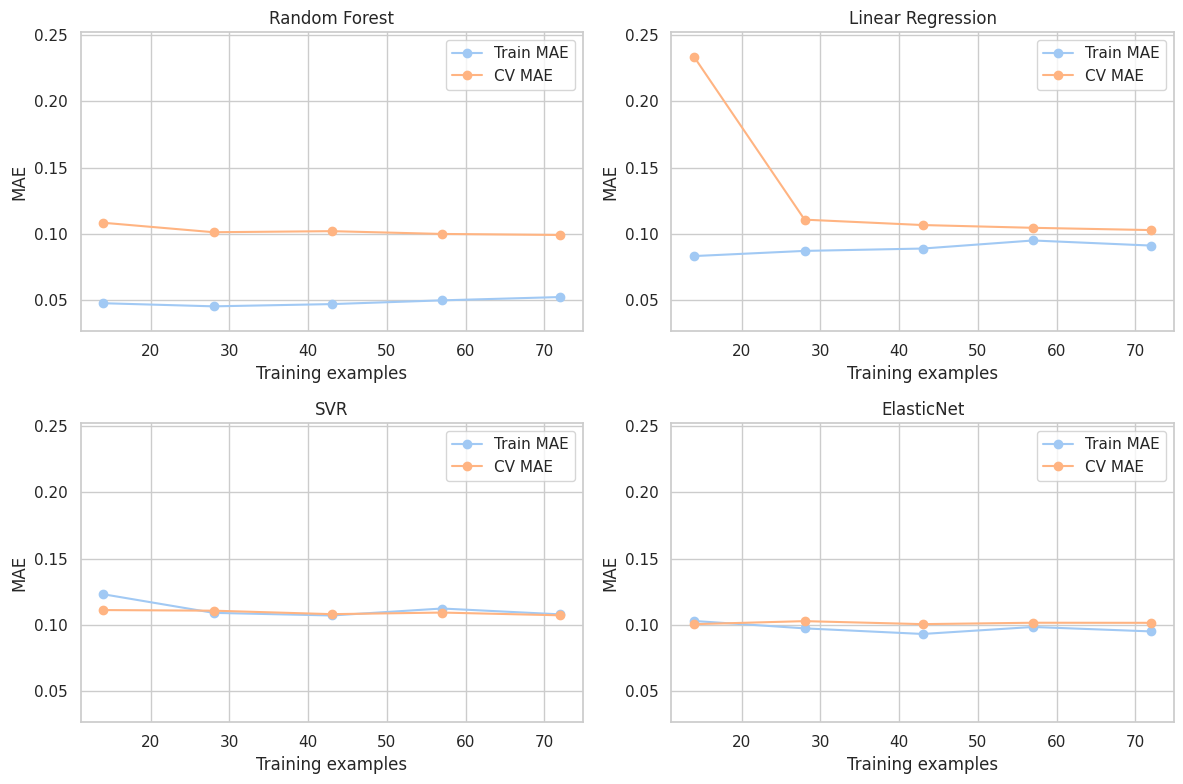

In [18]:
from sklearn.model_selection import learning_curve

# Compute global y-axis limits for all models' learning curves
train_scores_all = []
test_scores_all = []

# Helper to get scores for a model

def get_learning_curve_scores(estimator, X, y, scoring='neg_mean_absolute_error'):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=3, scoring=scoring, n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 5), shuffle=True, random_state=42
    )
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    return train_sizes, train_scores_mean, test_scores_mean

# Get scores for all models
train_sizes_rf, train_rf, test_rf = get_learning_curve_scores(rf_rs.best_estimator_, X_lc, y_lc)
train_sizes_lr, train_lr, test_lr = get_learning_curve_scores(lr_model, X_lc, y_lc)
train_sizes_svr, train_svr, test_svr = get_learning_curve_scores(svr_rs.best_estimator_, X_lc, y_lc)
train_sizes_enet, train_enet, test_enet = get_learning_curve_scores(enet_rs.best_estimator_, X_lc, y_lc)

all_scores = np.concatenate([train_rf, test_rf, train_lr, test_lr, train_svr, test_svr, train_enet, test_enet])
ymin, ymax = np.min(all_scores), np.max(all_scores)
margin = (ymax - ymin) * 0.1
ylim = (ymin - margin, ymax + margin)

def plot_learning_curve(estimator, X, y, title, scoring='neg_mean_absolute_error', ylim=None):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=3, scoring=scoring, n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 5), shuffle=True, random_state=42
    )
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    plt.figure(figsize=(5, 3))
    plt.plot(train_sizes, train_scores_mean, 'o-', label='Train MAE')
    plt.plot(train_sizes, test_scores_mean, 'o-', label='CV MAE')
    plt.title(title)
    plt.xlabel('Training examples')
    plt.ylabel('MAE')
    if ylim:
        plt.ylim(*ylim)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot all learning curves with the same y-axis scale, side by side
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
model_info = [
    (rf_rs.best_estimator_, 'Random Forest', axes[0, 0]),
    (lr_model, 'Linear Regression', axes[0, 1]),
    (svr_rs.best_estimator_, 'SVR', axes[1, 0]),
    (enet_rs.best_estimator_, 'ElasticNet', axes[1, 1]),
]
for estimator, title, ax in model_info:
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X_lc, y_lc, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 5), shuffle=True, random_state=42
    )
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    ax.plot(train_sizes, train_scores_mean, 'o-', label='Train MAE')
    ax.plot(train_sizes, test_scores_mean, 'o-', label='CV MAE')
    ax.set_title(title)
    ax.set_xlabel('Training examples')
    ax.set_ylabel('MAE')
    ax.set_ylim(*ylim)
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

Across the four models, the learning curves reveal different degrees of overfitting and bias–variance behavior. Random Forest shows a consistently low training MAE and a noticeably higher CV MAE with a stable gap that does not close much as data increases, indicating mild overfitting (high variance). Linear Regression starts with a large gap at small sample sizes (high CV error), but the train and CV MAE converge as data grows, suggesting low variance and limited overfitting, with performance mainly constrained by model bias. SVR exhibits very similar train and CV MAE across most training sizes, implying good generalization and minimal overfitting, though its overall error is higher than the best model. ElasticNet also shows closely aligned train and CV curves with small fluctuations, indicating little to no overfitting and a bias-controlled model. Overall, Random Forest is the most prone to overfitting, while Linear Regression, SVR, and ElasticNet generalize more consistently, with ElasticNet and SVR showing the best balance between bias and variance.

## Feature Importance

In [15]:
from sklearn.inspection import permutation_importance

model_feature_importances = {}

# Random Forest
try:
    rf_importances = rf_rs.best_estimator_.feature_importances_
    rf_features = X_train_fold.columns
    model_feature_importances['Random Forest'] = pd.DataFrame({
        'Feature': rf_features,
        'Importance': rf_importances
    }).sort_values('Importance', ascending=False)
except Exception as e:
    print(f"Random Forest importances error: {e}")

# Linear Regression
try:
    lr_coefs = np.abs(lr_model.coef_)
    lr_features = X_train_fold.columns
    model_feature_importances['Linear Regression'] = pd.DataFrame({
        'Feature': lr_features,
        'Importance': lr_coefs
    }).sort_values('Importance', ascending=False)
except Exception as e:
    print(f"Linear Regression importances error: {e}")

# Support Vector Machine
try:
    svm_perm = permutation_importance(svr_rs.best_estimator_, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1)
    svm_features = X_train_fold.columns
    model_feature_importances['Support Vector Machine'] = pd.DataFrame({
        'Feature': svm_features,
        'Importance': svm_perm.importances_mean
    }).sort_values('Importance', ascending=False)
except Exception as e:
    print(f"SVM importances error: {e}")

# ElasticNet
try:
    enet_coefs = np.abs(enet_rs.best_estimator_.coef_)
    enet_features = X_train_fold.columns
    model_feature_importances['ElasticNet'] = pd.DataFrame({
        'Feature': enet_features,
        'Importance': enet_coefs
    }).sort_values('Importance', ascending=False)
except Exception as e:
    print(f"ElasticNet importances error: {e}")

for model, df in model_feature_importances.items():
    print(f"Feature Importances for {model}:")
    display(df.head(10))

Feature Importances for Random Forest:


,Feature,Importance
2,sbdRpg_rolling5,0.173685
0,pdiffpg,0.166437
1,win_pct_rolling3,0.126730
7,o_oreb,0.125669
3,ast_to_rolling3,0.119465
6,roster_avg_rpg,0.101685
4,ast_to,0.100803
5,sbdRpg,0.085527


Feature Importances for Linear Regression:


,Feature,Importance
7,o_oreb,0.037917
1,win_pct_rolling3,0.024852
0,pdiffpg,0.022944
4,ast_to,0.019167
5,sbdRpg,0.016930
2,sbdRpg_rolling5,0.016116
3,ast_to_rolling3,0.009032
6,roster_avg_rpg,0.008417


Feature Importances for Support Vector Machine:


,Feature,Importance
7,o_oreb,0.032159
2,sbdRpg_rolling5,0.006563
6,roster_avg_rpg,-0.010108
3,ast_to_rolling3,-0.021459
4,ast_to,-0.029559
1,win_pct_rolling3,-0.033474
0,pdiffpg,-0.050397
5,sbdRpg,-0.075193


Feature Importances for ElasticNet:


,Feature,Importance
7,o_oreb,0.031608
1,win_pct_rolling3,0.024837
4,ast_to,0.016802
0,pdiffpg,0.016535
3,ast_to_rolling3,0.009826
2,sbdRpg_rolling5,0.005730
6,roster_avg_rpg,0.004388
5,sbdRpg,0.000000


Across all models, the features most consistently ranked as important are:

- Offensive rebounds per game (o_oreb)
- Recent win percentage (win_pct_rolling3)
- Point differential per game (pdiffpg)
- Assist-to-turnover ratio (ast_to and ast_to_rolling3)
- Defensive rebounding metrics (sbdRpg, sbdRpg_rolling5)
- Average rebounds by roster (roster_avg_rpg)

The Random Forest model places the highest importance on sbdRpg_rolling5, pdiffpg, and win_pct_rolling3, suggesting that recent defensive rebounding, point differential, and recent team performance are strong predictors of future success. Linear models (Linear Regression, ElasticNet) also highlight o_oreb, win_pct_rolling3, and pdiffpg as key features, but with more evenly distributed importance.

Support Vector Machine shows less clear separation, with some negative importances, indicating less interpretability or possible feature redundancy.

Overall, features capturing recent team performance, rebounding (both offensive and defensive), and ball control (assist-to-turnover) are the most influential in predicting next season’s team ranking. This suggests that both recent form and core efficiency metrics are critical for forecasting future success in this context.

## Statistical Significance Testing of Model Performance

To rigorously compare models, we test whether observed differences in performance metrics (e.g., MAE, RMSE) are statistically significant across cross-validation folds. We use the Wilcoxon signed-rank test for this purpose.

In [16]:
import scipy.stats as stats

# Models to compare
model_names = ['Random Forest', 'Linear Regression', 'Support Vector Machine', 'ElasticNet']

# Ranking: MAE (Rank)
print('Wilcoxon signed-rank test for MAE (Rank)')
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        m1, m2 = model_names[i], model_names[j]
        m1_mae = [df['MAE'].mean() for df in fold_ranking_metrics[m1]]
        m2_mae = [df['MAE'].mean() for df in fold_ranking_metrics[m2]]
        if len(m1_mae) == len(m2_mae) and len(m1_mae) > 1:
            w_stat, w_p_value = stats.wilcoxon(m1_mae, m2_mae)
            print(f"{m1} vs {m2}: Wilcoxon p={w_p_value:.4f}")
        else:
            print(f"{m1} vs {m2}: Not enough folds or unequal fold counts.")
print()

# Regression: MAE (Win%)
print('Wilcoxon signed-rank test for MAE (Win%)')
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        m1, m2 = model_names[i], model_names[j]
        m1_mae = [d['MAE'] for d in fold_regression_metrics[m1]]
        m2_mae = [d['MAE'] for d in fold_regression_metrics[m2]]
        if len(m1_mae) == len(m2_mae) and len(m1_mae) > 1:
            w_stat, w_p_value = stats.wilcoxon(m1_mae, m2_mae)
            print(f"{m1} vs {m2}: Wilcoxon p={w_p_value:.4f}")
        else:
            print(f"{m1} vs {m2}: Not enough folds or unequal fold counts.")
print()

# Regression: RMSE (Win%)
print('Wilcoxon signed-rank test for RMSE (Win%)')
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        m1, m2 = model_names[i], model_names[j]
        m1_rmse = [d['RMSE'] for d in fold_regression_metrics[m1]]
        m2_rmse = [d['RMSE'] for d in fold_regression_metrics[m2]]
        if len(m1_rmse) == len(m2_rmse) and len(m1_rmse) > 1:
            w_stat, w_p_value = stats.wilcoxon(m1_rmse, m2_rmse)
            print(f"{m1} vs {m2}: Wilcoxon p={w_p_value:.4f}")
        else:
            print(f"{m1} vs {m2}: Not enough folds or unequal fold counts.")

Wilcoxon signed-rank test for MAE (Rank)
Random Forest vs Linear Regression: Wilcoxon p=0.7500
Random Forest vs Support Vector Machine: Wilcoxon p=1.0000
Random Forest vs ElasticNet: Wilcoxon p=0.6250
Linear Regression vs Support Vector Machine: Wilcoxon p=0.3125
Linear Regression vs ElasticNet: Wilcoxon p=0.8750
Support Vector Machine vs ElasticNet: Wilcoxon p=0.3750

Wilcoxon signed-rank test for MAE (Win%)
Random Forest vs Linear Regression: Wilcoxon p=0.6250
Random Forest vs Support Vector Machine: Wilcoxon p=0.8125
Random Forest vs ElasticNet: Wilcoxon p=0.8125
Linear Regression vs Support Vector Machine: Wilcoxon p=0.8125
Linear Regression vs ElasticNet: Wilcoxon p=0.6250
Support Vector Machine vs ElasticNet: Wilcoxon p=0.1875

Wilcoxon signed-rank test for RMSE (Win%)
Random Forest vs Linear Regression: Wilcoxon p=1.0000
Random Forest vs Support Vector Machine: Wilcoxon p=0.4375
Random Forest vs ElasticNet: Wilcoxon p=0.4375
Linear Regression vs Support Vector Machine: Wilcoxon 

The statistical tests showed no significant differences in MAE (Rank), MAE (Win%), or RMSE (Win%) between the evaluated models (all p > 0.05).